   Account_ID Company_Size       Industry  Annual_Revenue  \
0           1        Small     Healthcare       4765975.0   
1           2        Small  Manufacturing       5683548.0   
2           3   Enterprise  Manufacturing       1722517.0   
3           4   Enterprise      Education       3481277.0   
4           5        Small        Finance       1023375.0   

   Monthly_Transactions Current_Plan  Account_Age_Months  Support_Tickets  \
0                   368     Business                  26                5   
1                   257        Basic                  75                4   
2                   424      Premium                  99                0   
3                   190     Standard                  33                0   
4                   262        Basic                  52                3   

  Sales_Contacted  Product_Usage_Score  Monthly_Fee Training_Attended  \
0              No                 55.0         2832               Yes   
1              No       

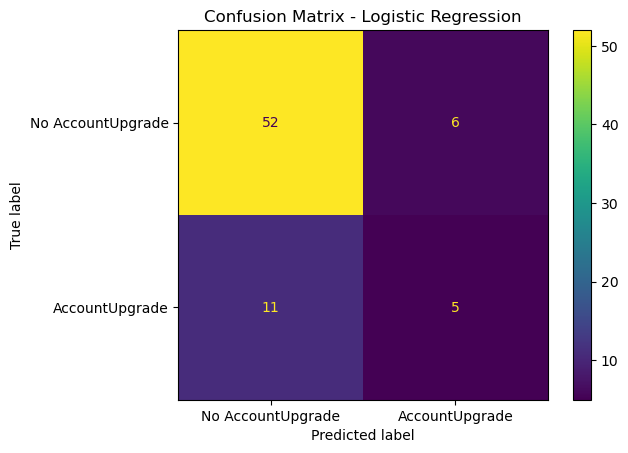

End Baseline Model - Logistic Regression
Begin Baseline Model - SVM (Support Vector Machine)
SVM predictions (first 10, preprocessed version): ['No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No']
SVM model trained successfully!
SVM (pipeline) predictions (first 10): ['No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No']
First 10 rows: Actual vs SVM_Predicted


,Actual,SVM_Predicted
0,No,No
1,No,No
2,Yes,No
3,No,No
4,No,No
5,No,No
6,Yes,Yes
7,No,No
8,Yes,Yes
9,No,No


=== SVM Evaluation ===
Confusion matrix (rows=true, cols=pred) - SVM:
 [[56  2]
 [11  5]]
Accuracy: 0.8243
Precision (Yes): 0.7143
Recall (Yes): 0.3125
F1-score (Yes): 0.4348

Classification report (SVM):
              precision    recall  f1-score   support

          No       0.84      0.97      0.90        58
         Yes       0.71      0.31      0.43        16

    accuracy                           0.82        74
   macro avg       0.78      0.64      0.67        74
weighted avg       0.81      0.82      0.80        74



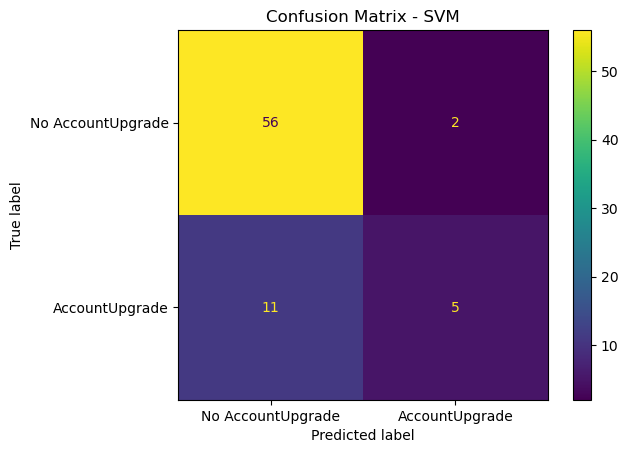

All evaluation metrics were calculated successfully.


In [18]:
import pandas as pd

# =========================
# • Load and inspect the dataset
# =========================
# File type is excel but CSV in nature
#df = pd.read_csv(r"business_account_upgrade_prediction_dataset.xls")
df = pd.read_excel("business_account_upgrade_prediction_dataset.xlsx")

print(df.head())
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())
print ("checking for null columns")
print(df.isnull().sum())
print(df.duplicated().sum())
print ("checked for duplicated rows")

# =========================
# • Understand the business problem
# ========================= 
print(
    "Predict which customers are likely to upgrade their business account.  \n"
    "Business Value \n"
    "* Improve marketing targeting \n"
    "* Increase revenue \n"
    "* Reduce wasted sales effort \n"
    "* Improve customer retention"
)


# =========================
# • Clean the data
# =========================

# Step i - Remove duplicates
print("Number of duplicate rows before cleaning:", df.duplicated().sum())
df = df.drop_duplicates()
print("Number of duplicate rows after cleaning:", df.duplicated().sum())

# Step ii - Check missing values
# Fill missing numerical values with the median 
df["Annual_Revenue"] = df["Annual_Revenue"].fillna(df["Annual_Revenue"].median())
df["Product_Usage_Score"] = df["Product_Usage_Score"].fillna(df["Product_Usage_Score"].median())

# Fill missing categorical column values with "Unknown"
df["Company_Size"] = df["Company_Size"].fillna("Unknown")
df["Industry"] = df["Industry"].fillna("Unknown")
df["Current_Plan"] = df["Current_Plan"].fillna("Unknown")
df["Sales_Contacted"] = df["Sales_Contacted"].fillna("Unknown")
df["Training_Attended"] = df["Training_Attended"].fillna("Unknown")

# Step iii - Clean text columns
text_columns = [
    "Company_Size",
    "Industry",
    "Current_Plan",
    "Sales_Contacted",
    "Training_Attended",
    "Upgraded_Account"
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()


# =========================
# • Identify the features and target variable
# =========================

# Step i - List All Features and target variable
feature_columns = [
    "Company_Size",
    "Industry",
    "Annual_Revenue",
    "Monthly_Transactions",
    "Current_Plan",
    "Account_Age_Months",
    "Support_Tickets",
    "Sales_Contacted",
    "Product_Usage_Score",
    "Monthly_Fee",
    "Training_Attended"
]

numerical_features = [
    "Annual_Revenue",
    "Monthly_Transactions",
    "Account_Age_Months",
    "Support_Tickets",
    "Product_Usage_Score",
    "Monthly_Fee"
]

categorical_features = [
    "Company_Size",
    "Industry",
    "Current_Plan",
    "Sales_Contacted",
    "Training_Attended"
]

# =========================
# • Define X and y 
# =========================

# Drop ID and target from features to avoid leakage
X = df[feature_columns]  # safer: explicitly use only your chosen features
y = df["Upgraded_Account"]

print("Features (X) sample:")
print(X.head())
print("Target (y) sample:")
print(y.head())


# =========================
# • Split the data into training and testing sets
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class balance (recommended for classification)
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


# =========================
# • Apply preprocessing
# =========================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Fit on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)


# ========================= ========================= =========================
# • Build a Baseline Model - Logistic Regression
# ========================= ========================= =========================
print("Begin Baseline Model - Logistic Regression")

from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_processed, y_train)
y_pred_logistic = baseline_model.predict(X_test_processed)
print("Logistic Regression predictions (first 10):", y_pred_logistic[:10])
print("Logistic Regression model trained successfully!")

# =========================
# • Pipeline Version (Logistic Regression)
# =========================

from sklearn.pipeline import Pipeline

clf_logistic = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# Train pipeline
clf_logistic.fit(X_train, y_train)

# Predict with pipeline
y_pred_logistic = clf_logistic.predict(X_test)

print("Logistic Regression (pipeline) predictions (first 10):", y_pred_logistic[:10])


# =========================
# • Model Accuracy & Metrics - Logistic Regression
# =========================

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import matplotlib.pyplot as plt

print("=== Logistic Regression Evaluation ===")
cm_logistic = confusion_matrix(y_test, y_pred_logistic, labels=["No", "Yes"])
print("Confusion Matrix (Logistic Regression):")
print(cm_logistic)

acc_logistic = accuracy_score(y_test, y_pred_logistic)
prec_logistic = precision_score(y_test, y_pred_logistic, pos_label="Yes")
recall_logistic = recall_score(y_test, y_pred_logistic, pos_label="Yes")
f1_logistic = f1_score(y_test, y_pred_logistic, pos_label="Yes")

print("Accuracy:", acc_logistic)
print("Precision (Yes):", prec_logistic)
print("Recall (Yes):", recall_logistic)
print("F1-Score (Yes):", f1_logistic)

print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_logistic, labels=["No", "Yes"]))

disp_logistic = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["No AccountUpgrade", "AccountUpgrade"]
)
disp_logistic.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

print("End Baseline Model - Logistic Regression")
print("==========================================================")


# ========================= ========================= =========================
# • Build a Baseline Model - SVM
# ========================= ========================= =========================

print("Begin Baseline Model - SVM (Support Vector Machine)")

from sklearn.svm import SVC

# Train SVM on preprocessed data (non-pipeline version)
svm_model = SVC(random_state=42, probability=True)
svm_model.fit(X_train_processed, y_train)
y_pred_svm = svm_model.predict(X_test_processed)
print("SVM predictions (first 10, preprocessed version):", y_pred_svm[:10])
print("SVM model trained successfully!")


# =========================
# • Pipeline Version (SVM)
# =========================

clf_svm = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="rbf", probability=True, class_weight=None, random_state=42))
])

# Train pipeline
clf_svm.fit(X_train, y_train)

# Predict with pipeline
y_pred_svm = clf_svm.predict(X_test)

print("SVM (pipeline) predictions (first 10):", y_pred_svm[:10])


# Optional: comparison DataFrame (works in notebooks)
try:
    from IPython.display import display
    svm_comparison_df = pd.DataFrame({
        "Actual": y_test.values,
        "SVM_Predicted": y_pred_svm
    })
    print("First 10 rows: Actual vs SVM_Predicted")
    display(svm_comparison_df.head(10))
except ImportError:
    print("First 10 rows: Actual vs SVM_Predicted")
    print(pd.DataFrame({
        "Actual": y_test.values,
        "SVM_Predicted": y_pred_svm
    }).head(10))


# =========================
# • Model Accuracy & Metrics - SVM
# =========================

print("=== SVM Evaluation ===")
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=["No", "Yes"])
print("Confusion matrix (rows=true, cols=pred) - SVM:\n", cm_svm)

acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, pos_label="Yes")
recall_svm = recall_score(y_test, y_pred_svm, pos_label="Yes")
f1_svm = f1_score(y_test, y_pred_svm, pos_label="Yes")

print(f"Accuracy: {acc_svm:.4f}")
print(f"Precision (Yes): {prec_svm:.4f}")
print(f"Recall (Yes): {recall_svm:.4f}")
print(f"F1-score (Yes): {f1_svm:.4f}")

print("\nClassification report (SVM):")
print(classification_report(y_test, y_pred_svm, labels=["No", "Yes"]))

disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["No AccountUpgrade", "AccountUpgrade"]
)
disp_svm.plot()
plt.title("Confusion Matrix - SVM")
plt.show()

print("All evaluation metrics were calculated successfully.")


# =========================
# • Question Times
# =========================


# 1. Which model performed better?
# ANSWER: The SVM model performed better overall, especially for the upgrade (“Yes”) class, because it achieved higher accuracy (0.82 vs 0.77), higher precision (0.71 vs 0.45), and a higher F1-score (0.43 vs 0.37).


# 2. Which metric is most important for your business problem?
# My most important metric is the F1-score for the “Yes” class, because we want to identify real upgrade 
# opportunities without wasting too much sales and marketing effort on customers who will not upgrade.


# 3. What do false positives and false negatives mean in your dataset?
# For SVM, using labels [“No”, “Yes”]:
#We had 2 False Positives (FP = 2): predicted “Yes” but the actual is “No”. The model says a customer is likely to upgrade, but they actually don’t.
# This meant that Business /marketing may spend time and budget contacting these customers, but get no upgrade.
# This indicates wasted sales time, marketing cost, possible customer annoyance.

# We had 11	False Negatives (FN = 11): predicted “No” but the actual is “Yes”. The model says a customer is unlikely to upgrade, but they actually would have.
# Hence, these customers may not be targeted or prioritized, so Business/ Marketting will miss out on 
# potential upgrades and revenue.
#This indicates loss of revenue opportunities and weaker customer engagement.




# 4. What is one possible limitation or bias in your model?
# One key limitation is class imbalance and limited data: there are many more “No” than “Yes” examples, 
# so the model learns to predict “No” much more confidently. This can bias it against correctly identifying 
# potential upgraders, especially in underrepresented customer segments.

# 5. Why should human judgment still be used?

# Human judgment should still be used because the model cannot capture all the contextual, qualitative, and 
# strategic information that sales and the Business have. Humans are needed to interpret the predictions, 
# override them when necessary, and ensure that important customers and edge cases are handled appropriately, 
# rather than relying solely on historical patterns.
# Also, the model only uses historical features (revenue, tickets, product usage, etc.). It does not know the 
# following; Current negotiations or relationships, Special deals, discounts, or strategic accounts, 
# Qualitative signals (tone in calls, emails, long-term relationship value)



# Assistant
This error occurs because the variable `df` (which likely contains your dataset) has not been defined or loaded before you try to use it. The code is trying to reference `df` somewhere to create the features or datasets, but `df` doesn't exist in the current namespace.

**Explanation:**
The code appears to be missing the initial steps where you would typically:
1. Import necessary libraries
2. Load your dataset into a DataFrame called `df`
3. Define `numerical_features`, `categorical_features`, `X_train`, `X_test`, `y_train`, etc.

Would you like me to provide the corrected code that includes the missing setup steps?